In [ ]:
from dfbr.utils.files import get_config, get_path
from dfbr.data.dataset import BikeDemandDataset, BikeOptTargetsDataset
from dfbr.models.station_targets import BikeStationTargets
from dfbr.models.station_targets_routing import BikeStationTargetsRouting, plot_rebalancing_route, print_route_sequence
from dfbr.models.cost_head import CostHead
from dfbr.models.mlp import MLP
from dfbr.eval.simulation import Sim, create_station_dict, create_event_df
from dfbr.training.train import evaluate
import datetime
import argparse
import shutil
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from torch.utils.data import DataLoader
from torch.optim import Adam
import torch.nn as nn
import torch
import pyepo
import torch.nn.functional as F
import numpy as np
import networkx as nx

In [2]:
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#Setup
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------

#Read config
config = get_config("baseline_healthy_ride.yaml")

#Create a dictionary of stations
station_dict = create_station_dict(config["paths"]["stations"], config["paths"]["station_dist_miles"], config["sim"]["start_inv_pct"])
#Sort by id to ensure alignment
station_ids = sorted(station_dict.keys())
#Get parameters for shapes of datasets and models
num_stations = len(station_dict)
capacities = [station_dict[sid].capacity for sid in station_ids]
current_inventory = [int(cap * config["sim"]["start_inv_pct"]) for cap in capacities]
max_cap = max(capacities)

#Create datasets
train_ds = BikeDemandDataset(
        file = config["paths"]["input"],
        start_date = config["data"]["train_start_date"],
        end_date = config["data"]["train_end_date"],
        target_cols= [str(id) for id in station_ids],
        input_scale_cols= ['mean_temp', 'precip', 'max_gust'],
        input_no_scale_cols=['sin_day_of_week', 'cos_day_of_week', 'sin_month', 'cos_month'],
        capacities=capacities,
        max_cap=max_cap
    )

training_stats = {'mean': train_ds.mean, 'std': train_ds.std, 'y_mean': train_ds.y_mean, 'y_std': train_ds.y_std}

test_ds = BikeDemandDataset(
        file = config["paths"]["input"],
        start_date = config["data"]["test_start_date"],
        end_date = config["data"]["test_end_date"],
        target_cols= [str(id) for id in station_ids],
        input_scale_cols= ['mean_temp', 'precip', 'max_gust'],
        input_no_scale_cols=['sin_day_of_week', 'cos_day_of_week', 'sin_month', 'cos_month'],
        capacities=capacities,
        max_cap=max_cap,
        is_train=False,
        scaling_factor=training_stats
)

In [3]:
opt_model = BikeStationTargetsRouting(
        num_stations=num_stations, 
        max_cap=max_cap, 
        total_inventory=sum(current_inventory),
        distance_matrix= config["paths"]["station_dist_min"],
        current_inventory=current_inventory,
        truck_cap=max_cap,
        max_travel_time= 60
)

Set parameter Username
Set parameter LicenseID to value 2774727
Academic license - for non-commercial use only - expires 2027-02-03


In [4]:
x, y, c = test_ds[150]

In [5]:
opt_model.setObj(c)
sol, obj = opt_model.solve()
sol_data = opt_model.extract_solution()

Solution extracted successfully! Plotting...


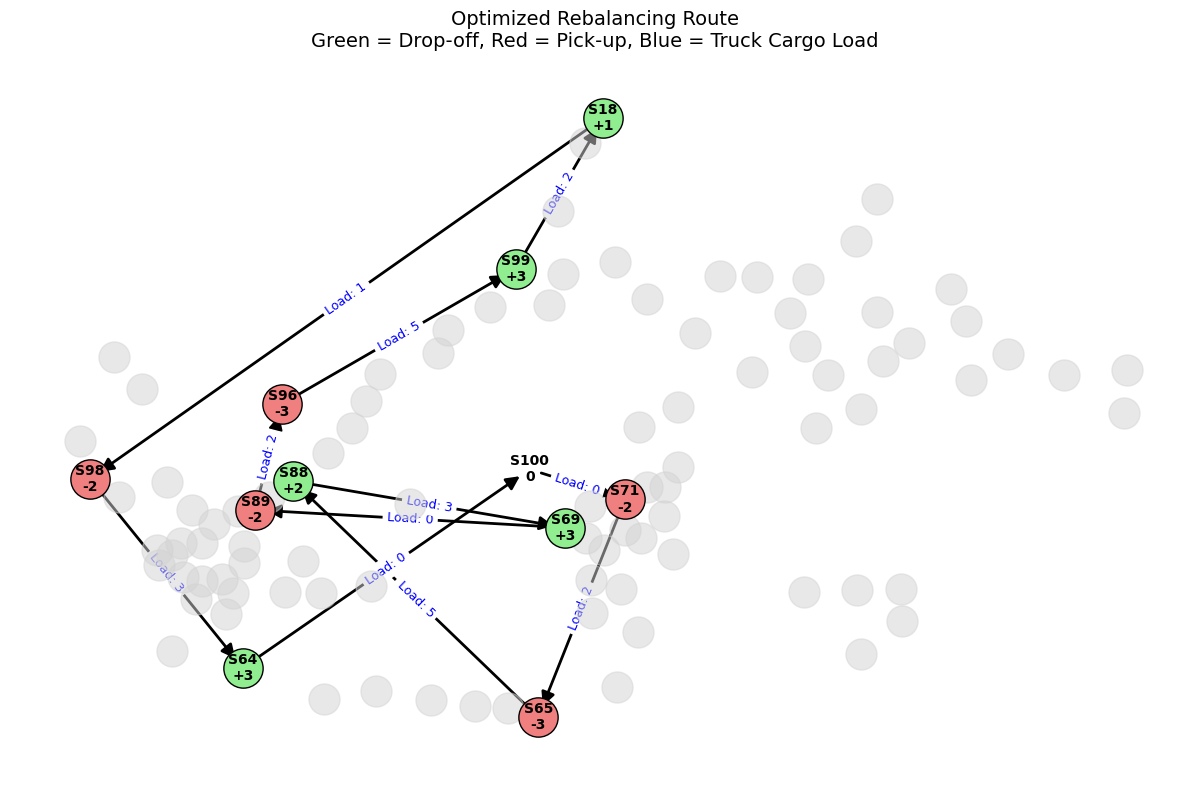

In [6]:
# Assuming your station_dict has .lon and .lat attributes
my_coords = {idx: (station.long, station.lat) for idx, (s_id, station) in enumerate(station_dict.items())}

# Give the depot a dummy coordinate if it's not in the dict (e.g., the average lon/lat)
avg_lon = sum(stat.long for stat in station_dict.values()) / len(station_dict)
avg_lat = sum(stat.lat for stat in station_dict.values()) / len(station_dict)
my_coords[opt_model.depot_idx] = (avg_lon, avg_lat)
if sol_data:
    print("Solution extracted successfully! Plotting...")
    plot_rebalancing_route(sol_data, my_coords)
else:
    print("Failed to extract a valid routing solution.")

In [ ]:
print_route_sequence(sol_data)


🚚 Shift Route Sequence:
Depot (S100) --[Load: 0]--> S71 --[Load: 2]--> S65 --[Load: 5]--> S88 --[Load: 3]--> S69 --[Load: 0]--> S89 --[Load: 2]--> S96 --[Load: 5]--> S99 --[Load: 2]--> S18 --[Load: 1]--> S98 --[Load: 3]--> S64 --[Load: 0]--> Depot (S100)
Total Stops: 11



: 